In [50]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/roaimkhan/student-perf-csv/student-por.csv


In [51]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset Understanding

In [52]:
# Loading the dataset
dataset = pd.read_csv("/kaggle/input/datasets/roaimkhan/student-perf-csv/student-por.csv")
df = pd.DataFrame(dataset)

In [53]:
#  How many rows and columns are present in the dataset?
print("===Required Tasks (Implement using python libraries):===\n")
print("1.How many rows and columns are present in the dataset?")
print(f" Columns : {len(df.columns)}")
print(f" Rows : {len(df)}")

===Required Tasks (Implement using python libraries):===

1.How many rows and columns are present in the dataset?
 Columns : 33
 Rows : 649


In [54]:

#  What are the names and meanings of all attributes?

attribute_meanings = {
    "school": "Student's school (binary: 'GP' - Gabriel Pereira or 'MS' - Mousinho da Silveira)",
    "sex": "Student's sex (binary: 'F' - female or 'M' - male)",
    "age": "Student's age (numeric: from 15 to 22)",
    "address": "Student's home address type (binary: 'U' - urban or 'R' - rural)",
    "famsize": "Family size (binary: 'LE3' - less than or equal to 3 or 'GT3' - greater than 3)",
    "Pstatus": "Parent's cohabitation status (binary: 'T' - living together or 'A' - apart)",
    "Medu": "Mother's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)",
    "Fedu": "Father's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)",
    "Mjob": "Mother's job (nominal: 'teacher', 'health' care related, civil 'services', 'at_home' or 'other')",
    "Fjob": "Father's job (nominal: 'teacher', 'health' care related, civil 'services', 'at_home' or 'other')",
    "reason": "Reason to choose this school (nominal: close to 'home', school 'reputation', 'course' preference or 'other')",
    "guardian": "Student's guardian (nominal: 'mother', 'father' or 'other')",
    "traveltime": "Home to school travel time (numeric: 1 - <15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour)",
    "studytime": "Weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)",
    "failures": "Number of past class failures (numeric: n if 1<=n<3, else 4)",
    "schoolsup": "Extra educational support (binary: yes or no)",
    "famsup": "Family educational support (binary: yes or no)",
    "paid": "Extra paid classes within the course subject (binary: yes or no)",
    "activities": "Extra-curricular activities (binary: yes or no)",
    "nursery": "Attended nursery school (binary: yes or no)",
    "higher": "Wants to take higher education (binary: yes or no)",
    "internet": "Internet access at home (binary: yes or no)",
    "romantic": "With a romantic relationship (binary: yes or no)",
    "famrel": "Quality of family relationships (numeric: from 1 - very bad to 5 - excellent)",
    "freetime": "Free time after school (numeric: from 1 - very low to 5 - very high)",
    "goout": "Going out with friends (numeric: from 1 - very low to 5 - very high)",
    "Dalc": "Workday alcohol consumption (numeric: from 1 - very low to 5 - very high)",
    "Walc": "Weekend alcohol consumption (numeric: from 1 - very low to 5 - very high)",
    "health": "Current health status (numeric: from 1 - very bad to 5 - very good)",
    "absences": "Number of school absences (numeric: from 0 to 93)",
    "G1": "First period grade (numeric: from 0 to 20)",
    "G2": "Second period grade (numeric: from 0 to 20)",
    "G3": "Final grade (numeric: from 0 to 20, output target)"
}


print("Names and meanings of all attributes")
attributes = df.columns.tolist()
for  col, attr in enumerate(attributes):
    print(f"Attribute {col} :\n   Name: {attr}\n   Meaning : {attribute_meanings[attr]}")



Names and meanings of all attributes
Attribute 0 :
   Name: school
   Meaning : Student's school (binary: 'GP' - Gabriel Pereira or 'MS' - Mousinho da Silveira)
Attribute 1 :
   Name: sex
   Meaning : Student's sex (binary: 'F' - female or 'M' - male)
Attribute 2 :
   Name: age
   Meaning : Student's age (numeric: from 15 to 22)
Attribute 3 :
   Name: address
   Meaning : Student's home address type (binary: 'U' - urban or 'R' - rural)
Attribute 4 :
   Name: famsize
   Meaning : Family size (binary: 'LE3' - less than or equal to 3 or 'GT3' - greater than 3)
Attribute 5 :
   Name: Pstatus
   Meaning : Parent's cohabitation status (binary: 'T' - living together or 'A' - apart)
Attribute 6 :
   Name: Medu
   Meaning : Mother's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)
Attribute 7 :
   Name: Fedu
   Meaning : Father's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th 

In [55]:
#  What are the data types of each column?
for  col, attr in enumerate(df.columns):
    print(f"Datatype of column {col}: {df[attr].dtype}")

Datatype of column 0: object
Datatype of column 1: object
Datatype of column 2: int64
Datatype of column 3: object
Datatype of column 4: object
Datatype of column 5: object
Datatype of column 6: int64
Datatype of column 7: int64
Datatype of column 8: object
Datatype of column 9: object
Datatype of column 10: object
Datatype of column 11: object
Datatype of column 12: int64
Datatype of column 13: int64
Datatype of column 14: int64
Datatype of column 15: object
Datatype of column 16: object
Datatype of column 17: object
Datatype of column 18: object
Datatype of column 19: object
Datatype of column 20: object
Datatype of column 21: object
Datatype of column 22: object
Datatype of column 23: int64
Datatype of column 24: int64
Datatype of column 25: int64
Datatype of column 26: int64
Datatype of column 27: int64
Datatype of column 28: int64
Datatype of column 29: int64
Datatype of column 30: int64
Datatype of column 31: int64
Datatype of column 32: int64


In [56]:
#  Are there any missing or duplicate values in the dataset?
print(f"Missing values in the dataset : {df.isnull().sum().sum()}")
duplicate_rows = df.duplicated()
print(f"Duplicate values in the dataset : {duplicate_rows}")
if duplicate_rows.any():
    print("Yes there are duplicate values")
else:
    print("No there are no duplicate values")


Missing values in the dataset : 0
Duplicate values in the dataset : 0      False
1      False
2      False
3      False
4      False
       ...  
644    False
645    False
646    False
647    False
648    False
Length: 649, dtype: bool
No there are no duplicate values


In [57]:

#  Which variables are numerical and which are categorical?
for  col, attr in enumerate(df.columns):
    if df[attr].dtype == "int64":
        print(f"{attr} : numerical")
    else :
        print(f"{attr} : categorical")
        

school : categorical
sex : categorical
age : numerical
address : categorical
famsize : categorical
Pstatus : categorical
Medu : numerical
Fedu : numerical
Mjob : categorical
Fjob : categorical
reason : categorical
guardian : categorical
traveltime : numerical
studytime : numerical
failures : numerical
schoolsup : categorical
famsup : categorical
paid : categorical
activities : categorical
nursery : categorical
higher : categorical
internet : categorical
romantic : categorical
famrel : numerical
freetime : numerical
goout : numerical
Dalc : numerical
Walc : numerical
health : numerical
absences : numerical
G1 : numerical
G2 : numerical
G3 : numerical


# 2 . Data Preprocessing 

**1. How will missing values (if any) be handled?**

Missing data in numerical columns will replaced by 'mean' (incase of normal distribution) or mode('skewed'). In categorical columns it will be replaced by mode.

**2. How will categorical variables be converted into numerical form?**
In this dataset there are two types of categorical columns:

**Binary :**
        Binary categorical columns will be converted to 0s an 1s.
        
**Non-Binary :**
        Non-Binary columns will be converted to numberical form through label encoder

In [58]:
#separting numerical and categorical columns:
x = df.copy()

x = x.drop(["G3"], axis=1)
cat_cols = x.select_dtypes(["category","object"]).columns.to_list()
num_cols = x.select_dtypes(["number"]).columns.to_list()

print(cat_cols)
print(num_cols)
print(len(cat_cols)+len(num_cols))

['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
32


In [59]:
# classifying category by cardinality
binary_cat = [i for i in cat_cols if x[i].nunique() == 2]
non_binary_cat = [i for i in cat_cols if x[i].nunique() > 2]

#converting true binary cols in to 0/1 
binary_map = {
  'school': {'GP':0, 'MS':1},
  'sex': {'F':0, 'M':1},
  'address': {'R':0, 'U':1},
  'famsize': {'LE3':0, 'GT3':1},
  'Pstatus': {'T':0, 'A':1},
  'schoolsup': {'no':0, 'yes':1},
  'famsup': {'no':0, 'yes':1},
  'paid': {'no':0, 'yes':1},
  'activities': {'no':0, 'yes':1},
  'nursery': {'no':0, 'yes':1},
  'higher': {'no':0, 'yes':1},
  'internet': {'no':0, 'yes':1},
  'romantic': {'no':0, 'yes':1},
}

df_bi = df.copy()
for col,val in binary_map.items():
    df_bi[col] = df[col].map(val)

df_bi

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,1,1,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,0,0,17,1,1,0,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,0,0,15,1,0,0,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,0,0,15,1,1,0,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,0,0,16,1,1,0,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,1,0,19,0,1,0,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,1,0,18,1,0,0,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,1,0,18,1,1,0,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,1,1,17,1,0,0,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


In [60]:
#converting non-binary cols into num
x_encoded = df_bi.copy()
en = LabelEncoder()
for col in non_binary_cat:
    x_encoded[col] = en.fit_transform(x_encoded[col]) 

x_encoded

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,1,1,4,4,0,4,...,4,3,4,1,1,3,4,0,11,11
1,0,0,17,1,1,0,1,1,0,2,...,5,3,3,1,1,3,2,9,11,11
2,0,0,15,1,0,0,1,1,0,2,...,4,3,2,2,3,3,6,12,13,12
3,0,0,15,1,1,0,4,2,1,3,...,3,2,2,1,1,5,0,14,14,14
4,0,0,16,1,1,0,3,3,2,2,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,1,0,19,0,1,0,2,3,3,2,...,5,4,2,1,2,5,4,10,11,10
645,1,0,18,1,0,0,3,1,4,3,...,4,3,4,1,1,1,4,15,15,16
646,1,0,18,1,1,0,1,1,2,2,...,1,1,1,1,1,5,6,11,12,9
647,1,1,17,1,0,0,3,1,3,3,...,2,4,5,3,4,2,6,10,10,10


In [61]:
#making sure all columns are coverted to numerics
non_Encoded = x_encoded.select_dtypes(["category","object"]).columns.to_list()
if non_Encoded:
    print(f"There is still a column left to be encoded : {non_Encoded}")
else:
    print("All columns coverted to numerics")

All columns coverted to numerics


In [62]:
# How will the target variable be created from G3?
y = df["G3"]
y = y.astype(int)
y_encoded = y.copy()
for num,val in enumerate(y):
    if val >=10:
        y_encoded[num] = 1
    else:
        y_encoded[num] = 0
        
print(y_encoded)


0      1
1      1
2      1
3      1
4      1
      ..
644    1
645    1
646    0
647    1
648    1
Name: G3, Length: 649, dtype: int64


# 3. Feature Selection

In [63]:
co_dataset = x_encoded.copy()
co_dataset["G3"] = y_encoded

# # Can we do feature engineering by adding a new feature

co_dataset["grade_avg"] = (co_dataset["G1"] + co_dataset["G2"]) / 2
co_dataset["grade_improvement"] = co_dataset["G2"] - co_dataset["G1"]
co_dataset["study_efficiency"] = co_dataset["studytime"] / (co_dataset["absences"] + 1)

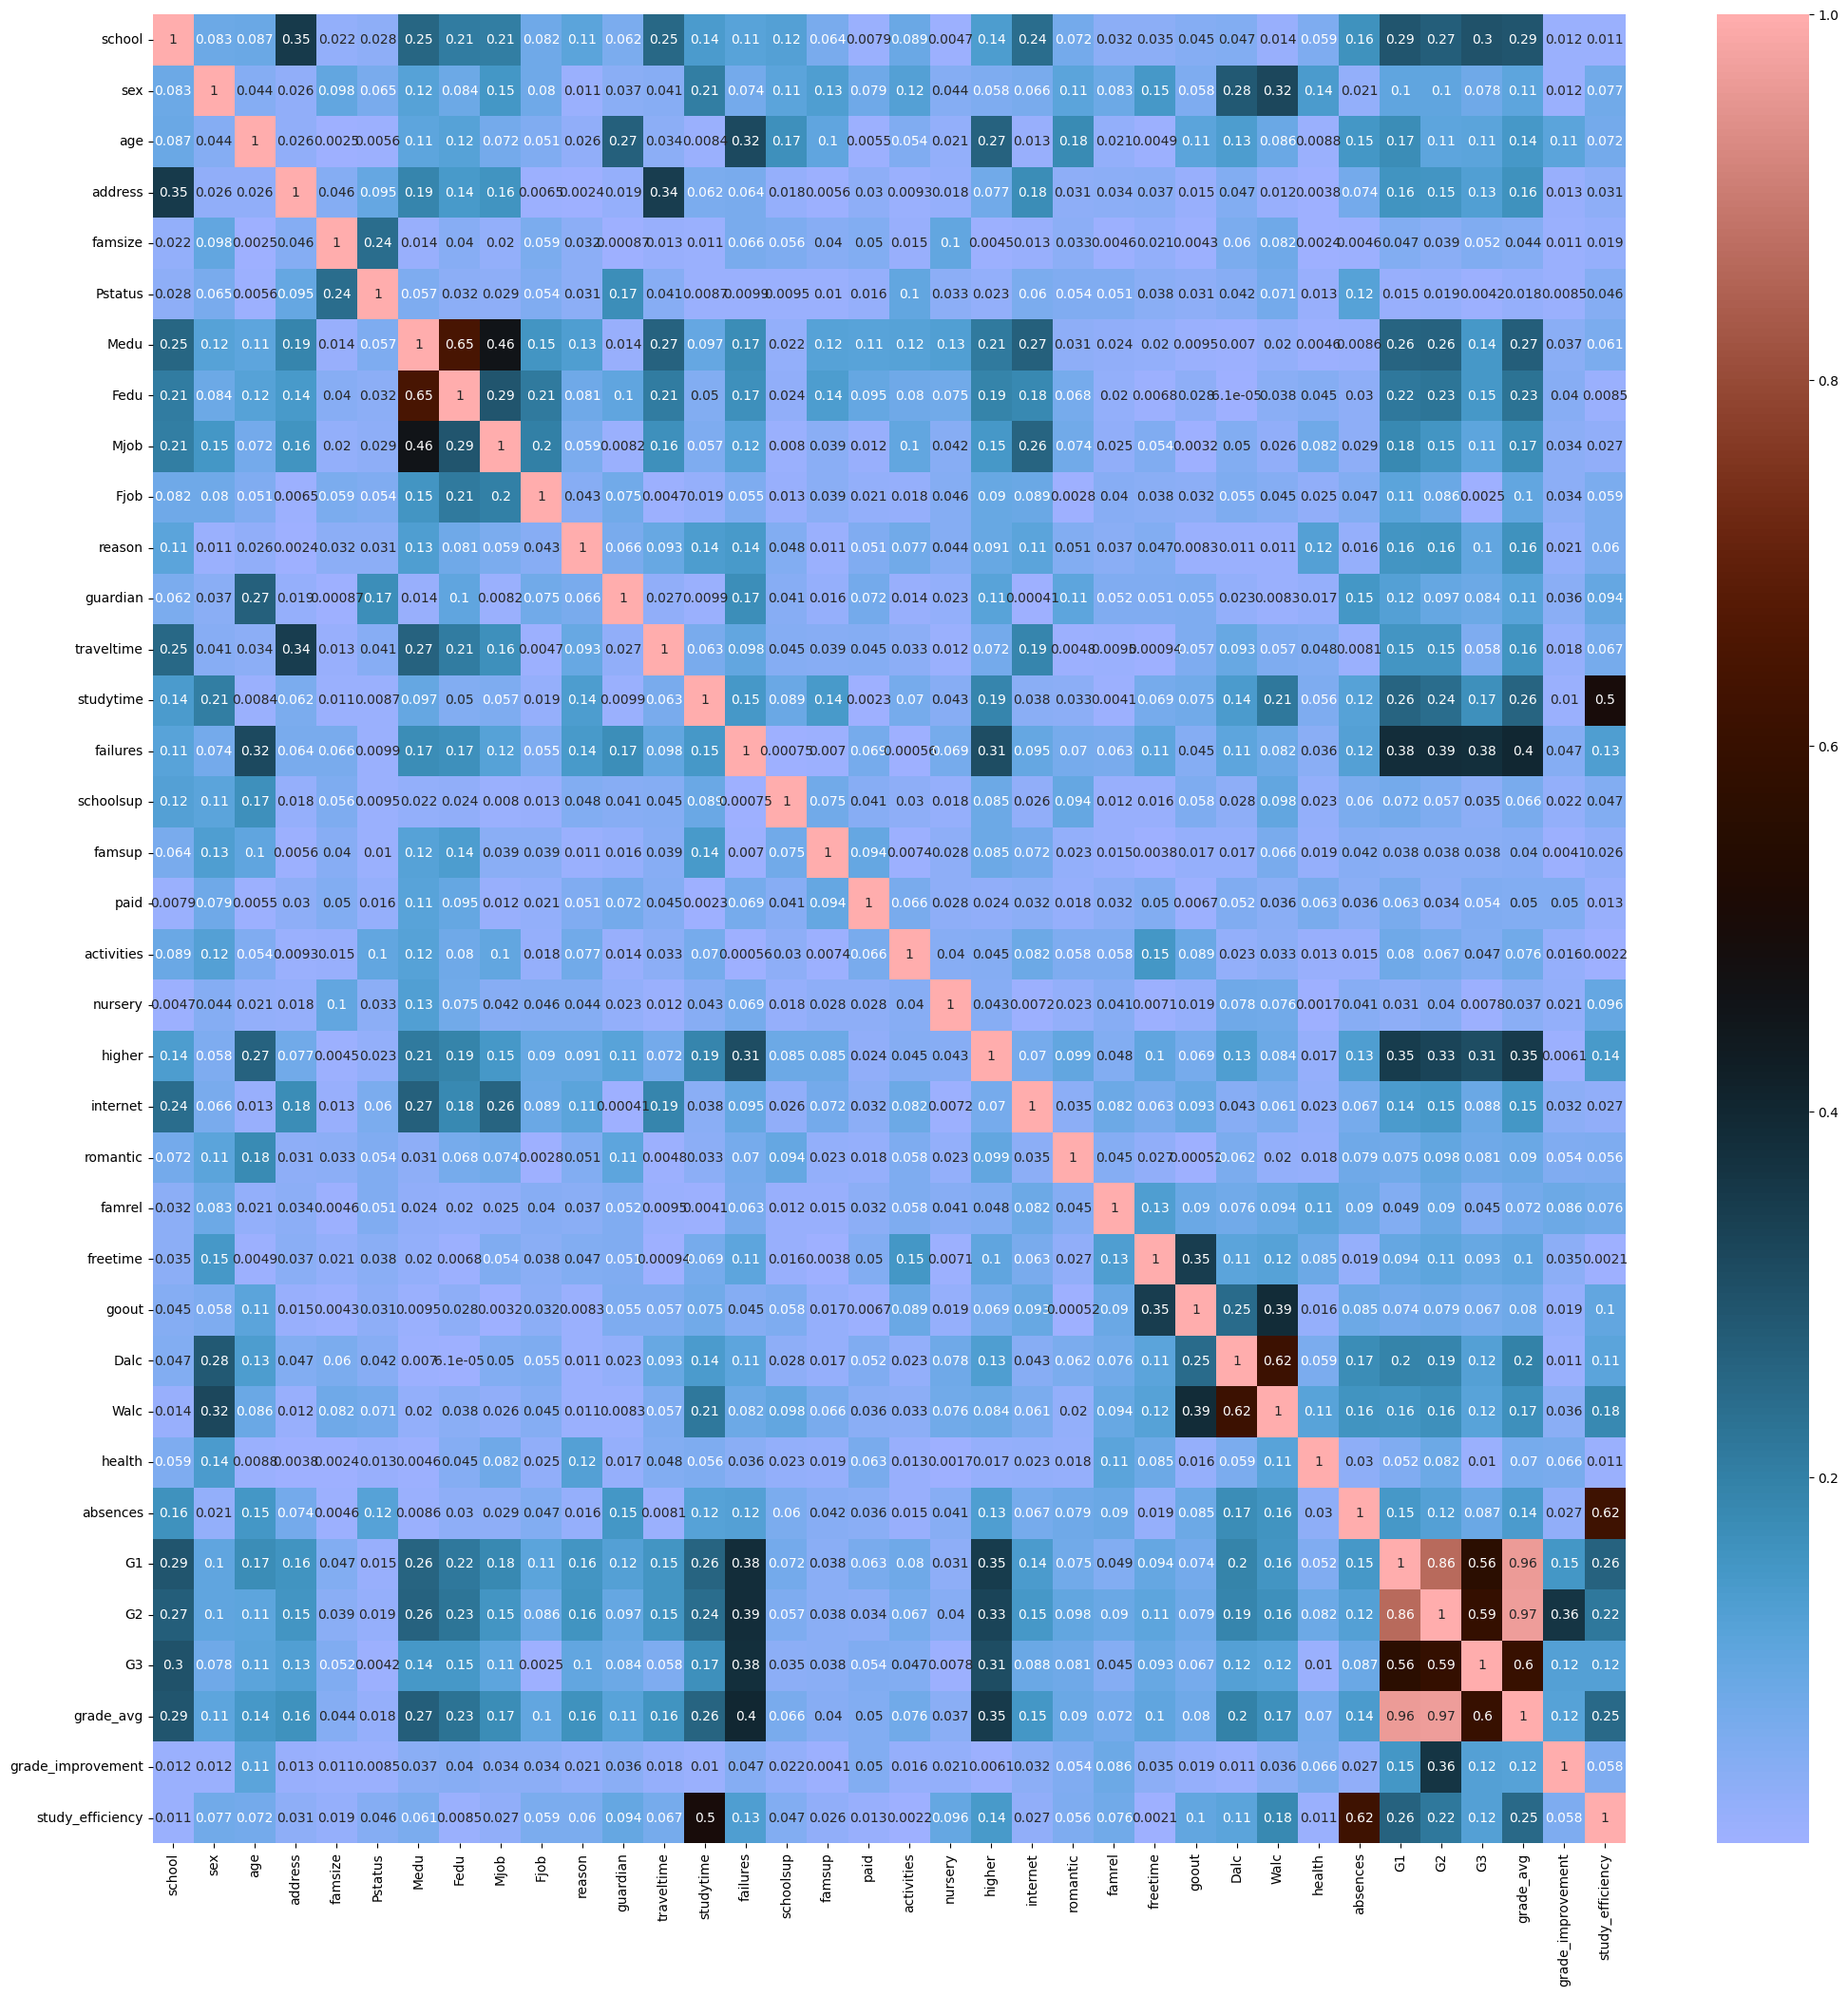

In [64]:
cov_mat = co_dataset.corr().abs()
def show_corrlation():
    plt.figure(figsize=(25,25))
    sns.heatmap(
        cov_mat,
        annot = True,
        cmap = 'berlin'
    )
    plt.plot()
    plt.show()

show_corrlation()

In [65]:
threshold = 0.15
selected_Feat = []
excluded_Feat = []
for num , feat in enumerate(cov_mat["G3"]):
    if feat > threshold:
        selected_Feat.append(cov_mat.columns[num])
    else:
        excluded_Feat.append(cov_mat.columns[num])
        
selected_Feat.remove("G3")
selected_Feat.remove("higher")  #removing because of the required inputs features
selected_Feat.remove("school")  #removing because of the required inputs features
selected_Feat.append("absences")#appending because of the required inputs features

print("1.Which features are most relevant for predicting student performance?")
print(selected_Feat,"\n")
print("2.Which columns are excluded from the model and on what criteria?")
print(f"Follwing features are excluded from model because their relativity is lower than the threshold defined : {excluded_Feat}")

1.Which features are most relevant for predicting student performance?
['studytime', 'failures', 'G1', 'G2', 'grade_avg', 'absences'] 

2.Which columns are excluded from the model and on what criteria?
Follwing features are excluded from model because their relativity is lower than the threshold defined : ['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'grade_improvement', 'study_efficiency']


# 4. Exploratory Data Analysis (EDA)

**What is the distribution of final grades (G3)?**

**The data is approximately normally distributed, with a slight right skew if we ignore the outlier group at the zero mark.**

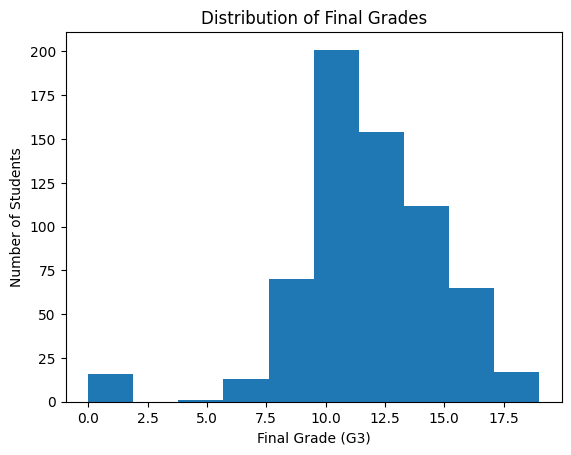

In [66]:
plt.hist(y, bins=10)
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")
plt.show()

In [67]:
y_original = df["G3"].astype(int)
co_dataset_eda = x_encoded.copy()
co_dataset_eda["G3"] = y_original  # real grades, not binary

[47, 66, 67, 69, 70, 71, 76, 77, 94, 95, 105, 106, 108, 121, 149, 218, 224, 289, 298, 312, 327, 338, 343, 349, 383, 390, 393, 434, 458, 497, 502, 503, 523, 536, 606]
12.819047619047621
10.683962264150944


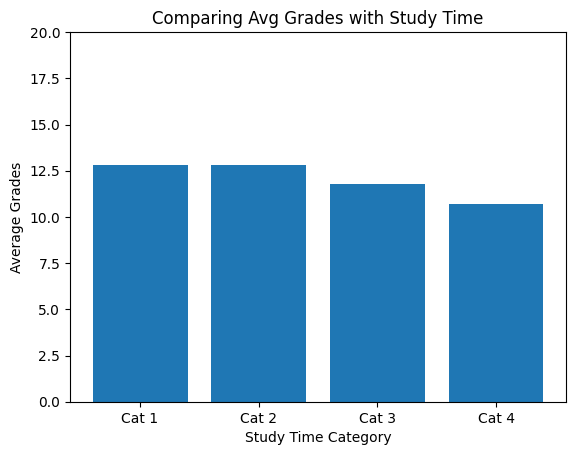

In [68]:
# grouping students into 4 categories according to their studytime with category 1 including students with highest studytime 
cat4 = [] 
cat3 = []
cat2 = []
cat1 = []
for ind,val in enumerate(co_dataset["studytime"]):
    if val == 1:
        cat4.append(ind)
    elif val == 2:
        cat3.append(ind)
    elif val == 3:
        cat2.append(ind)
    elif val == 4:
        cat1.append(ind)
print(cat1)

# finding average for each group
cat4_avg_grade = ((co_dataset_eda.loc[cat4,["G1","G2","G3"]]).mean(axis = 1)).mean()
cat3_avg_grade = ((co_dataset_eda.loc[cat3,["G1","G2","G3"]]).mean(axis = 1)).mean()
cat2_avg_grade = ((co_dataset_eda.loc[cat2,["G1","G2","G3"]]).mean(axis = 1)).mean()
cat1_avg_grade = ((co_dataset_eda.loc[cat1,["G1","G2","G3"]]).mean(axis = 1)).mean()
print(cat1_avg_grade)
print(cat4_avg_grade)

# plotting bar chart
categories = ['Cat 1', 'Cat 2', 'Cat 3', 'Cat 4']
heights = [cat1_avg_grade,cat2_avg_grade,cat3_avg_grade,cat4_avg_grade]
plt.bar(categories,heights)
plt.title("Comparing Avg Grades with Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Average Grades")
plt.ylim(0, 20)
plt.show()

**The bar plot shows that studytime  do effect the grade output !**

**How do absences affect student results?**

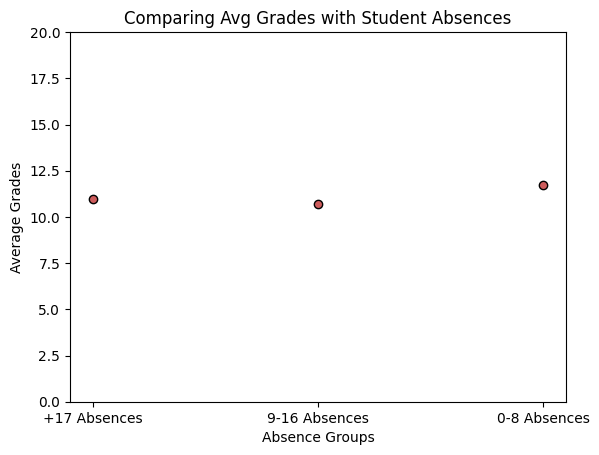

In [69]:
abs4 = [] 
abs3 = []
abs2 = []

for ind, val in enumerate(co_dataset["absences"]):
    if val <= 8:
        abs4.append(ind)
    elif val <= 16:
        abs3.append(ind)
    else:
        abs2.append(ind)
        

abs4_avg_grade = ((co_dataset_eda.loc[abs4,["G1","G2","G3"]]).mean(axis = 1)).mean()
abs3_avg_grade = ((co_dataset_eda.loc[abs3,["G1","G2","G3"]]).mean(axis = 1)).mean()
abs2_avg_grade = ((co_dataset_eda.loc[abs2,["G1","G2","G3"]]).mean(axis = 1)).mean()

# Proper ordering for the plot
heights = [ abs2_avg_grade, abs3_avg_grade, abs4_avg_grade]
categories = ["+17 Absences", "9-16 Absences", "0-8 Absences"]

# Using a bar chart makes this data much easier to read than a scatter plot
plt.scatter(categories, heights, color='indianred', edgecolor='black')
plt.title("Comparing Avg Grades with Student Absences")
plt.xlabel("Absence Groups")
plt.ylabel("Average Grades")
plt.ylim(0, 20) 
plt.show()

In [70]:
print(f"17-24 group size: {len(abs2)}")
print(f"9-16 group size : {len(abs3)}")
print(f"0-8 group size  : {len(abs4)}")

# Check raw distributions, not just means
for name, group in [("25+", abs1), ("17-24", abs2), ("9-16", abs3), ("0-8", abs4)]:
    grades = co_dataset_eda.loc[group, ["G1","G2","G3"]].mean(axis=1)
    print(f"{name}: mean={grades.mean():.2f}, std={grades.std():.2f}, n={len(group)}")

17-24 group size: 11
9-16 group size : 66
0-8 group size  : 572
25+: mean=12.11, std=3.91, n=3
17-24: mean=10.97, std=2.55, n=11
9-16: mean=10.72, std=2.47, n=66
0-8: mean=11.74, std=2.86, n=572


**Does previous failure history impact on final grades?**

3


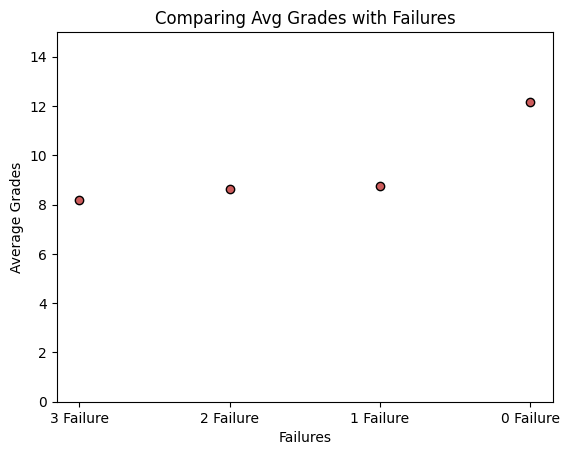

In [71]:
print(co_dataset["failures"].max())

fail4 = [] 
fail3 = []
fail2 = []
fail1 = []
for ind,val in enumerate(co_dataset["failures"]):
    if val == 0:
        fail4.append(ind)
    elif val == 1:
        fail3.append(ind)
    elif val == 2:
        fail2.append(ind)
    elif val == 3:
        fail1.append(ind)
        

fail4_avg_grade = ((co_dataset_eda.loc[fail4,["G1","G2","G3"]]).mean(axis = 1)).mean()
fail3_avg_grade = ((co_dataset_eda.loc[fail3,["G1","G2","G3"]]).mean(axis = 1)).mean()
fail2_avg_grade = ((co_dataset_eda.loc[fail2,["G1","G2","G3"]]).mean(axis = 1)).mean()
fail1_avg_grade = ((co_dataset_eda.loc[fail1,["G1","G2","G3"]]).mean(axis = 1)).mean()

# Proper ordering for the plot
heights = [fail1_avg_grade, fail2_avg_grade, fail3_avg_grade, fail4_avg_grade]
categories = ["3 Failure", "2 Failure", "1 Failure", "0 Failure"]

# Using a bar chart makes this data much easier to read than a scatter plot
plt.scatter(categories, heights, color='indianred', edgecolor='black')
plt.title("Comparing Avg Grades with Failures")
plt.xlabel("Failures")
plt.ylabel("Average Grades")
plt.ylim(0, 15) 
plt.show()

**What correlations exist between variables?**

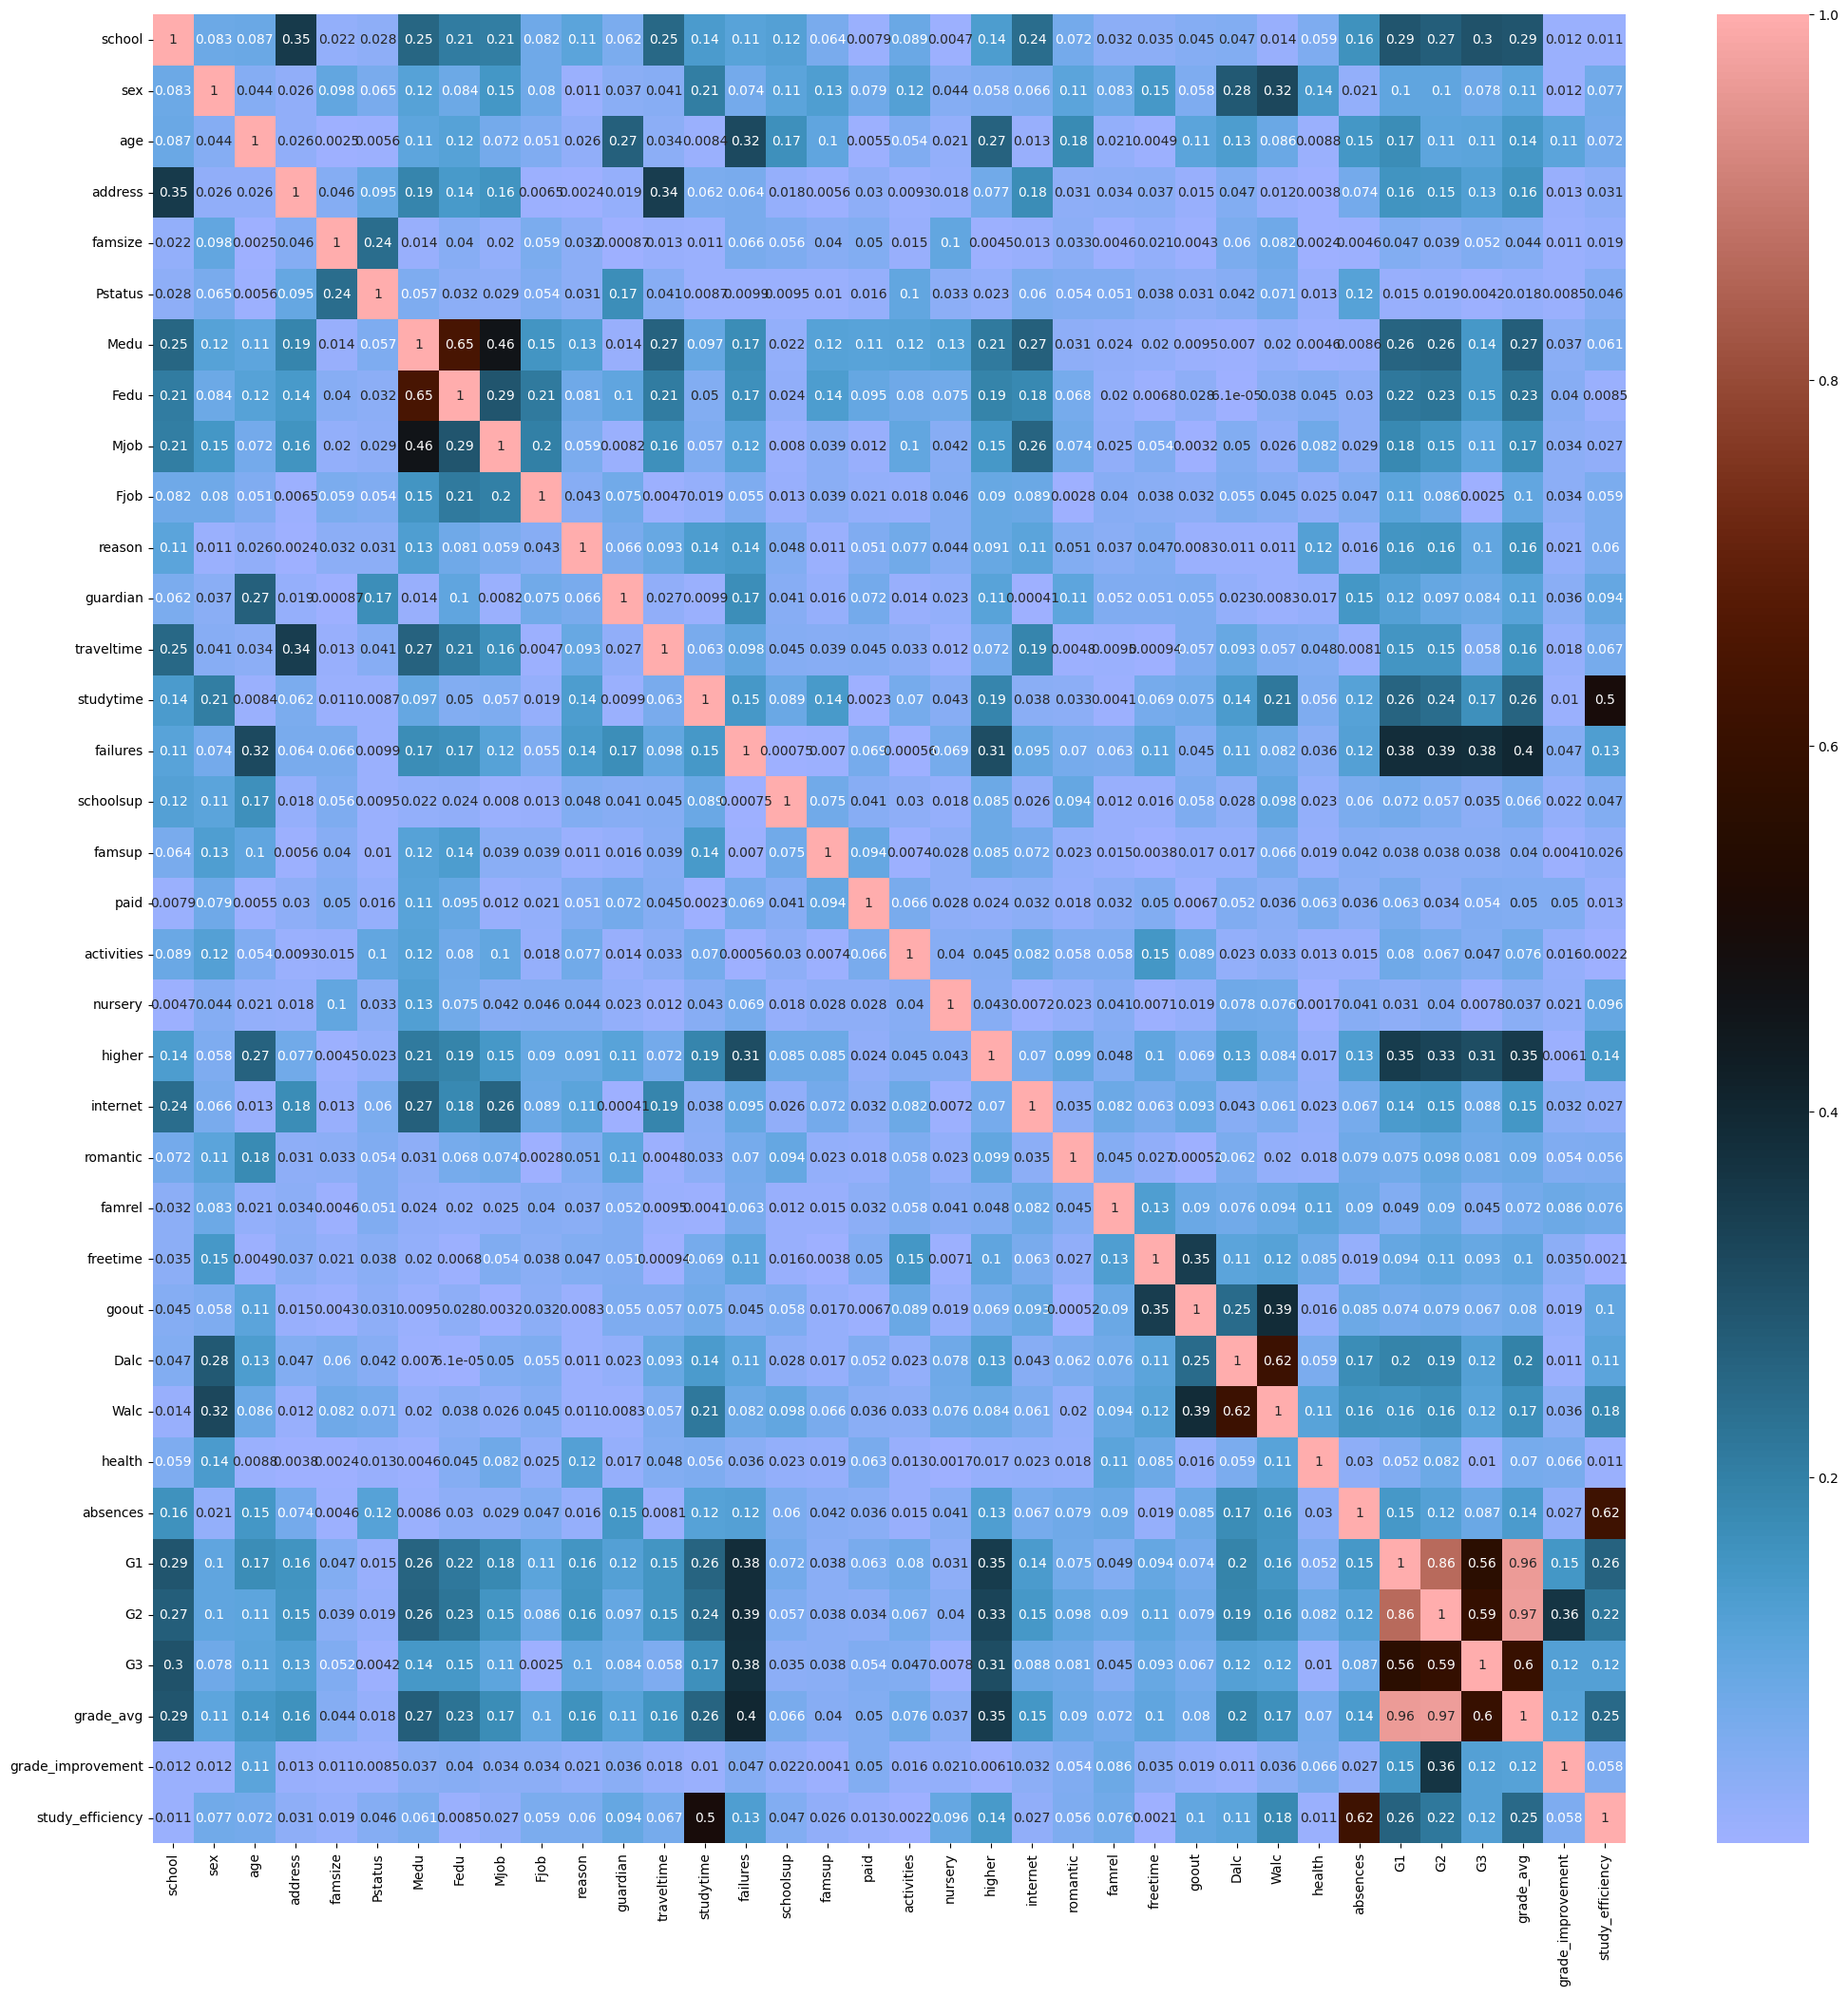

In [72]:
show_corrlation()

# 5. Machine Learning Implementation

**A. Linear Regression (Regression Task)**

In [73]:
X = co_dataset[selected_Feat]
Y = df["G3"]

print(X.head())
print(Y.head())

   studytime  failures  G1  G2  grade_avg  absences
0          2         0   0  11        5.5         4
1          2         0   9  11       10.0         2
2          2         0  12  13       12.5         6
3          3         0  14  14       14.0         0
4          2         0  11  13       12.0         0
0    11
1    11
2    12
3    14
4    13
Name: G3, dtype: int64


In [74]:
print(X.shape)
print(Y.shape)

(649, 6)
(649,)


In [75]:
X_train  , X_test , Y_train , Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42) 
print(X_train.shape)
print(Y_train.shape) 

(454, 6)
(454,)


In [76]:
linear_model = LinearRegression()
linear_model.fit(X_train , Y_train)

LinearRegression()

In [77]:
pred = linear_model.predict(X_test)
actual = Y_test
data = {
    "prediction" : pred,
    "actual" : actual
}
data = pd.DataFrame(data=data)
print(data)

     prediction  actual
636   18.613446      19
220   11.359988      12
594   18.697518      18
429   11.244569      11
72    11.778907      11
..          ...     ...
310    9.349647      10
256    8.499983       8
137   11.861031      11
274    9.705873      10
235   12.818483      12

[195 rows x 2 columns]


In [78]:
print(f"MAE : {mean_absolute_error(Y_test,pred):.2f}")
print(f"MSE : {mean_squared_error(Y_test,pred):.2f}")
print(f"R2 : {r2_score(Y_test,pred):.2f}")

MAE : 0.75
MSE : 1.30
R2 : 0.88


**B. Logistic Regression (Classification Task)**

In [79]:
X = co_dataset[selected_Feat]
Y = co_dataset["G3"]

In [80]:
X_train  , X_test , Y_train , Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42) 
print(X_train.shape)
print(Y_train.shape) 

(454, 6)
(454,)


In [81]:
logis_model = LogisticRegression()
logis_model.fit(X_train , Y_train)

LogisticRegression()

In [82]:
pred = logis_model.predict(X_test)
actual = Y_test
data = {
    "prediction" : pred,
    "actual" : actual
}
data = pd.DataFrame(data=data)
print(data)

     prediction  actual
636           1       1
220           1       1
594           1       1
429           1       1
72            1       1
..          ...     ...
310           0       1
256           0       0
137           1       1
274           1       1
235           1       1

[195 rows x 2 columns]


In [83]:
cm = confusion_matrix(Y_test,pred)
print(f"confusion_matrix : \n{cm}")

tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)

print(f"\nConfusion Matrix Breakdown:")
print(f"True Positives  (Predicted Pass, Actually Pass) : {tp}")
print(f"True Negatives  (Predicted Fail, Actually Fail) : {tn}")
print(f"False Positives (Predicted Pass, Actually Fail) : {fp}")
print(f"False Negatives (Predicted Fail, Actually Pass) : {fn}")
print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")

confusion_matrix : 
[[ 20   6]
 [  7 162]]

Confusion Matrix Breakdown:
True Positives  (Predicted Pass, Actually Pass) : 162
True Negatives  (Predicted Fail, Actually Fail) : 20
False Positives (Predicted Pass, Actually Fail) : 6
False Negatives (Predicted Fail, Actually Pass) : 7

Accuracy  : 0.9333
Precision : 0.9643
Recall    : 0.9586


**Model Accuracy Interpretation:**
- Accuracy: Overall correct predictions out of all predictions.
- Precision: Of all students predicted to pass, how many actually passed.
- Recall: Of all students who actually passed, how many did we correctly identify.
- False Negatives are costly here, predicting a student passes when they actually fail means no intervention.

**C. Bayesian Probability**

In [84]:
# Bayesian Probability



# calculating Prior
total = len(co_dataset)
pass_count = (co_dataset["G3"] == 1).sum()
fail_count = (co_dataset["G3"] == 0).sum()

P_pass = pass_count / total
P_fail = fail_count / total

print(f"P(Pass)  = {P_pass:.4f}")
print(f"P(Fail)  = {P_fail:.4f}")

#1: P(Pass | High Study Time) 


# High study time = studytime == 4 (>10 hrs/week)

high_study = co_dataset[co_dataset["studytime"] == 4]
P_high_study = len(high_study) / total

# Likelihood: P(High Study | Pass) = among passers, how many studied hard?
pass_students = co_dataset[co_dataset["G3"] == 1]
P_highstudy_given_pass = (pass_students["studytime"] == 4).sum() / pass_count

# Bayes
P_pass_given_highstudy = (P_highstudy_given_pass * P_pass) / P_high_study

print(f"\n── Q1: Effect of High Study Time ──")
print(f"P(HighStudy)              = {P_high_study:.4f}")
print(f"P(HighStudy | Pass)       = {P_highstudy_given_pass:.4f}")
print(f"P(Pass | HighStudy)       = {P_pass_given_highstudy:.4f}")

# Compare against baseline
print(f"Baseline P(Pass)          = {P_pass:.4f}")
print(f"Lift from high study      = {P_pass_given_highstudy - P_pass:+.4f}")

P(Pass)  = 0.8459
P(Fail)  = 0.1541

── Q1: Effect of High Study Time ──
P(HighStudy)              = 0.0539
P(HighStudy | Pass)       = 0.0601
P(Pass | HighStudy)       = 0.9429
Baseline P(Pass)          = 0.8459
Lift from high study      = +0.0969


** How does failure history affect probability of passing?**

In [85]:
#2: P(Pass | Failure History > 0) 

has_failures = co_dataset[co_dataset["failures"] > 0]
P_has_failures = len(has_failures) / total

# Likelihood: P(Has Failures | Pass)
P_failures_given_pass = (pass_students["failures"] > 0).sum() / pass_count

# Bayes
P_pass_given_failures = (P_failures_given_pass * P_pass) / P_has_failures

print(f"\n── Q2: Effect of Failure History ──")
print(f"P(HasFailures)            = {P_has_failures:.4f}")
print(f"P(HasFailures | Pass)     = {P_failures_given_pass:.4f}")
print(f"P(Pass | HasFailures)     = {P_pass_given_failures:.4f}")
print(f"Baseline P(Pass)          = {P_pass:.4f}")
print(f"Drag from failure history = {P_pass_given_failures - P_pass:+.4f}")


── Q2: Effect of Failure History ──
P(HasFailures)            = 0.1541
P(HasFailures | Pass)     = 0.0929
P(Pass | HasFailures)     = 0.5100
Baseline P(Pass)          = 0.8459
Drag from failure history = -0.3359


# 6. Model Evaluation

**Q1: What is the difference between regression and classification outputs?**
Linear Regression outputs a continuous numerical value (predicted G3 score, e.g. 13.7). 
Logistic Regression outputs a binary class label (Pass=1 or Fail=0). 
Same input features, fundamentally different output types.

**Q2: Which model is more interpretable for academic use?**
Linear Regression is more interpretable — a teacher can directly see "this student is predicted to score 12/20". 
A Pass/Fail label from Logistic Regression loses the grade detail, making it harder to take targeted action.

**Q3: Which model is more practical for real-world deployment?**
Logistic Regression is more practical for deployment — it gives a clear actionable decision (intervene or not). 
Institutions rarely act on a predicted score of 11.3 vs 12.1, but they do act on predicted failure flags.

**Q4: How does feature selection affect both models?**
Features below the 0.15 correlation threshold were excluded. This reduces noise and prevents overfitting in both models. 
For Linear Regression, irrelevant features inflate MSE. For Logistic Regression, they distort the decision boundary. 
The engineered features (grade_avg, grade_improvement, study_efficiency) improved signal quality for both.

# 7. Prediction System

In [86]:
def predict():
    studytime = int(input("Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs): "))
    failures  = int(input("Number of Past Failures (0-3): "))
    absences  = int(input("Number of Absences: "))
    G1        = float(input("First Period Grade G1 (0-20): "))
    G2        = float(input("Second Period Grade G2 (0-20): "))
    grade_avg = (G2+G1)/2
    data = [[studytime , failures , G1 , G2 , grade_avg , absences]]
    feats = ["studytime"  ,"failures" ,"G1" ,"G2" ,"grade_avg" ,"absences"]
    data_df = pd.DataFrame(data=data , columns = feats)
    linear_pred = linear_model.predict(data_df)
    logis_pred = logis_model.predict(data_df)

    print(f"G3 : {linear_pred[0]:.2f}")
    print(f"Verdict (pass/fail) : {"PASS ✓" if logis_pred[0] == 1 else "FAIL ✗"}")
    
predict()

Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs):  4
Number of Past Failures (0-3):  3
Number of Absences:  23
First Period Grade G1 (0-20):  2
Second Period Grade G2 (0-20):  1


G3 : 1.40
Verdict (pass/fail) : FAIL ✗
